In [4]:
import pandas as pd
import numpy as np

# ============================================================
# PHASE 1 — LOAD & INSPECT
# ============================================================

df = pd.read_csv('../data/raw/online_retail_II.csv', encoding='ISO-8859-1')
print("=== RAW SHAPE ===")
print(df.shape)
print()

print("=== DTYPES ===")
print(df.dtypes)
print()

print("=== MISSING VALUES ===")
print(df.isnull().sum())
print()

print("=== UNIQUE CUSTOMERS (incl. missing) ===")
print(df['Customer ID'].nunique())
print()

print("=== DATE RANGE ===")
print(df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
print()

print("=== CANCELLED INVOICES (Invoice starting with 'C') ===")
cancelled_count = df['Invoice'].astype(str).str.startswith('C').sum()
print(cancelled_count, "rows out of", len(df))
print()

print("=== NEGATIVE / ZERO QUANTITY OR PRICE ROWS ===")
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Zero/negative Price:", (df['Price'] <= 0).sum())


# ============================================================
# PHASE 1B — CLEAN
# ============================================================

df_clean = df.copy()

# 1. Drop rows with missing Customer ID — can't build cohorts for anonymous transactions
df_clean = df_clean.dropna(subset=['Customer ID'])

# 2. Remove cancelled invoices (Invoice starting with 'C') — these are returns, not purchases
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# 3. Remove non-positive quantity or price (data errors/adjustments, not real sales)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# 4. Make sure InvoiceDate is proper datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 5. Customer ID as a clean integer (loads as float because of earlier NaNs)
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# 6. Add TotalPrice — useful later, and a sanity-check column for now
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

print()
print("=== CLEANED SHAPE ===")
print(df_clean.shape)
print()

print("=== ROWS REMOVED & WHY ===")
print("Original rows:", len(df))
print("Final rows:", len(df_clean))
print("Removed:", len(df) - len(df_clean))
print()

print("=== FINAL UNIQUE CUSTOMERS ===")
print(df_clean['Customer ID'].nunique())
print()

print("=== FINAL DATE RANGE ===")
print(df_clean['InvoiceDate'].min(), "to", df_clean['InvoiceDate'].max())

# Save cleaned data for Phase 2
df_clean.to_csv('../data/raw/cleaned_retail.csv', index=False)
print()
print("Saved cleaned file to data/raw/cleaned_retail.csv")

=== RAW SHAPE ===
(1067371, 8)

=== DTYPES ===
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

=== MISSING VALUES ===
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

=== UNIQUE CUSTOMERS (incl. missing) ===
5942

=== DATE RANGE ===
2009-12-01 07:45:00 to 2011-12-09 12:50:00

=== CANCELLED INVOICES (Invoice starting with 'C') ===
19494 rows out of 1067371

=== NEGATIVE / ZERO QUANTITY OR PRICE ROWS ===
Negative Quantity: 22950
Zero/negative Price: 6207

=== CLEANED SHAPE ===
(805549, 9)

=== ROWS REMOVED & WHY ===
Original rows: 1067371
Final rows: 805549
Removed: 261822

=== FINAL UNIQUE CUSTOMERS ===
5878

=== FINAL DATE RANGE ===
2009-12-01 07:45:00 to 2011-12-09 12:50:00

Saved cleaned file to d

In [5]:
import pandas as pd
import numpy as np

# ============================================================
# PHASE 2 — COHORT ASSIGNMENT
# ============================================================

df = pd.read_csv('../data/raw/cleaned_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 1. Truncate each transaction to its month (drop the day/time, keep year-month)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# 2. Find each customer's FIRST purchase month — this is their "cohort"
cohort_lookup = df.groupby('Customer ID')['InvoiceMonth'].min().reset_index()
cohort_lookup.columns = ['Customer ID', 'CohortMonth']

df = df.merge(cohort_lookup, on='Customer ID', how='left')

# 3. Calculate "months since first purchase" for every transaction
#    (this is the x-axis of the retention heatmap)
def period_diff(later, earlier):
    return (later.year - earlier.year) * 12 + (later.month - earlier.month)

df['CohortIndex'] = df.apply(
    lambda row: period_diff(row['InvoiceMonth'], row['CohortMonth']), axis=1
)

print("=== SAMPLE WITH COHORT FIELDS ===")
print(df[['Customer ID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head(10))
print()

# ============================================================
# PHASE 2B — BUILD RETENTION TABLE (the heatmap data)
# ============================================================

# Count of UNIQUE customers active in each (CohortMonth, CohortIndex) combination
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_data.columns = ['CohortMonth', 'CohortIndex', 'NumCustomers']

# Pivot into the classic cohort grid: rows = cohort month, columns = months since first purchase
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='NumCustomers')

# Cohort size = number of customers at CohortIndex 0 (their first month)
cohort_sizes = cohort_counts.iloc[:, 0]

# Convert counts to RETENTION % — this is what actually goes in the heatmap
retention_table = cohort_counts.divide(cohort_sizes, axis=0) * 100
retention_table = retention_table.round(1)

print("=== COHORT SIZES (customers acquired per month) ===")
print(cohort_sizes)
print()

print("=== RETENTION TABLE (% retained, rows=cohort month, cols=months since) ===")
print(retention_table.iloc[:, :6])  # first 6 months only, for readability

# Save for next phase (funnel + visualization)
retention_table.to_csv('../outputs/retention_table.csv')
cohort_sizes.to_csv('../outputs/cohort_sizes.csv')
df.to_csv('../data/raw/cohort_assigned.csv', index=False)

print()
print("Saved: outputs/retention_table.csv, outputs/cohort_sizes.csv, data/raw/cohort_assigned.csv")

=== SAMPLE WITH COHORT FIELDS ===
   Customer ID InvoiceMonth CohortMonth  CohortIndex
0        13085      2009-12     2009-12            0
1        13085      2009-12     2009-12            0
2        13085      2009-12     2009-12            0
3        13085      2009-12     2009-12            0
4        13085      2009-12     2009-12            0
5        13085      2009-12     2009-12            0
6        13085      2009-12     2009-12            0
7        13085      2009-12     2009-12            0
8        13085      2009-12     2009-12            0
9        13085      2009-12     2009-12            0

=== COHORT SIZES (customers acquired per month) ===
CohortMonth
2009-12    955.0
2010-01    383.0
2010-02    374.0
2010-03    443.0
2010-04    294.0
2010-05    254.0
2010-06    270.0
2010-07    186.0
2010-08    162.0
2010-09    243.0
2010-10    377.0
2010-11    325.0
2010-12     76.0
2011-01     71.0
2011-02    124.0
2011-03    179.0
2011-04    106.0
2011-05    111.0
2011-06    1

In [6]:
import pandas as pd

# ============================================================
# PHASE 3 — PURCHASE-FREQUENCY FUNNEL
# Stage 1: First purchase (acquired)
# Stage 2: 2nd purchase within 90 days of first (activated)
# Stage 3: 3rd+ purchase within 180 days of first (loyal/repeat)
# ============================================================

df = pd.read_csv('../data/raw/cleaned_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 1. Collapse line items into ONE row per actual purchase event (Invoice)
#    A single order can have many product rows -- we only care about the order itself here
orders = df.groupby(['Customer ID', 'Invoice'])['InvoiceDate'].min().reset_index()
orders = orders.sort_values(['Customer ID', 'InvoiceDate'])

# 2. Rank each customer's orders chronologically: 1st order, 2nd order, 3rd order...
orders['PurchaseRank'] = orders.groupby('Customer ID').cumcount() + 1

# 3. Attach each customer's first purchase date to every one of their rows
first_purchase = orders[orders['PurchaseRank'] == 1][['Customer ID', 'InvoiceDate']]
first_purchase = first_purchase.rename(columns={'InvoiceDate': 'FirstPurchaseDate'})
orders = orders.merge(first_purchase, on='Customer ID')

# 4. Days elapsed between this order and the customer's first order
orders['DaysSinceFirst'] = (orders['InvoiceDate'] - orders['FirstPurchaseDate']).dt.days

print("=== SAMPLE ORDER-LEVEL DATA ===")
print(orders.head(10))
print()

# ============================================================
# PHASE 3B — BUILD THE FUNNEL (stages are strictly nested)
# ============================================================

# Stage 1: everyone who ever made a first purchase
stage1_customers = orders['Customer ID'].nunique()

# Stage 2: customers whose 2nd purchase happened within 90 days of their 1st
second_orders = orders[orders['PurchaseRank'] == 2]
stage2_ids = set(second_orders[second_orders['DaysSinceFirst'] <= 90]['Customer ID'])
stage2_customers = len(stage2_ids)

# Stage 3: customers who ALREADY qualified for Stage 2, AND have a 3rd-or-later
# purchase within 180 days of their 1st. Funnel stages must be strictly nested --
# Stage 3 can never be larger than Stage 2, so we filter to stage2_ids first.
third_plus_orders = orders[(orders['PurchaseRank'] >= 3) & (orders['Customer ID'].isin(stage2_ids))]
stage3_ids = set(third_plus_orders[third_plus_orders['DaysSinceFirst'] <= 180]['Customer ID'])
stage3_customers = len(stage3_ids)

funnel = pd.DataFrame({
    'Stage': ['1. First Purchase (Acquired)',
              '2. Second Purchase within 90 days (Activated)',
              '3. Third+ Purchase within 180 days (Loyal)'],
    'Customers': [stage1_customers, stage2_customers, stage3_customers]
})

# % of Stage 1 (overall funnel conversion)
funnel['% of Total'] = (funnel['Customers'] / stage1_customers * 100).round(1)

# % conversion from the PREVIOUS stage (step-to-step drop-off)
funnel['% from Previous Stage'] = (
    funnel['Customers'] / funnel['Customers'].shift(1) * 100
).round(1)
funnel.loc[0, '% from Previous Stage'] = 100.0  # stage 1 is always the 100% baseline

print("=== FUNNEL TABLE ===")
print(funnel.to_string(index=False))

# Save for the visualization phase
funnel.to_csv('../outputs/funnel_table.csv', index=False)
orders.to_csv('../data/raw/orders_ranked.csv', index=False)

print()
print("Saved: outputs/funnel_table.csv, data/raw/orders_ranked.csv")

=== SAMPLE ORDER-LEVEL DATA ===
   Customer ID  Invoice         InvoiceDate  PurchaseRank   FirstPurchaseDate  \
0        12346   491725 2009-12-14 08:34:00             1 2009-12-14 08:34:00   
1        12346   491742 2009-12-14 11:00:00             2 2009-12-14 08:34:00   
2        12346   491744 2009-12-14 11:02:00             3 2009-12-14 08:34:00   
3        12346   492718 2009-12-18 10:47:00             4 2009-12-14 08:34:00   
4        12346   492722 2009-12-18 10:55:00             5 2009-12-14 08:34:00   
5        12346   493410 2010-01-04 09:24:00             6 2009-12-14 08:34:00   
6        12346   493412 2010-01-04 09:53:00             7 2009-12-14 08:34:00   
7        12346   494450 2010-01-14 13:50:00             8 2009-12-14 08:34:00   
8        12346   495295 2010-01-22 13:30:00             9 2009-12-14 08:34:00   
9        12346   499763 2010-03-02 13:08:00            10 2009-12-14 08:34:00   

   DaysSinceFirst  
0               0  
1               0  
2               

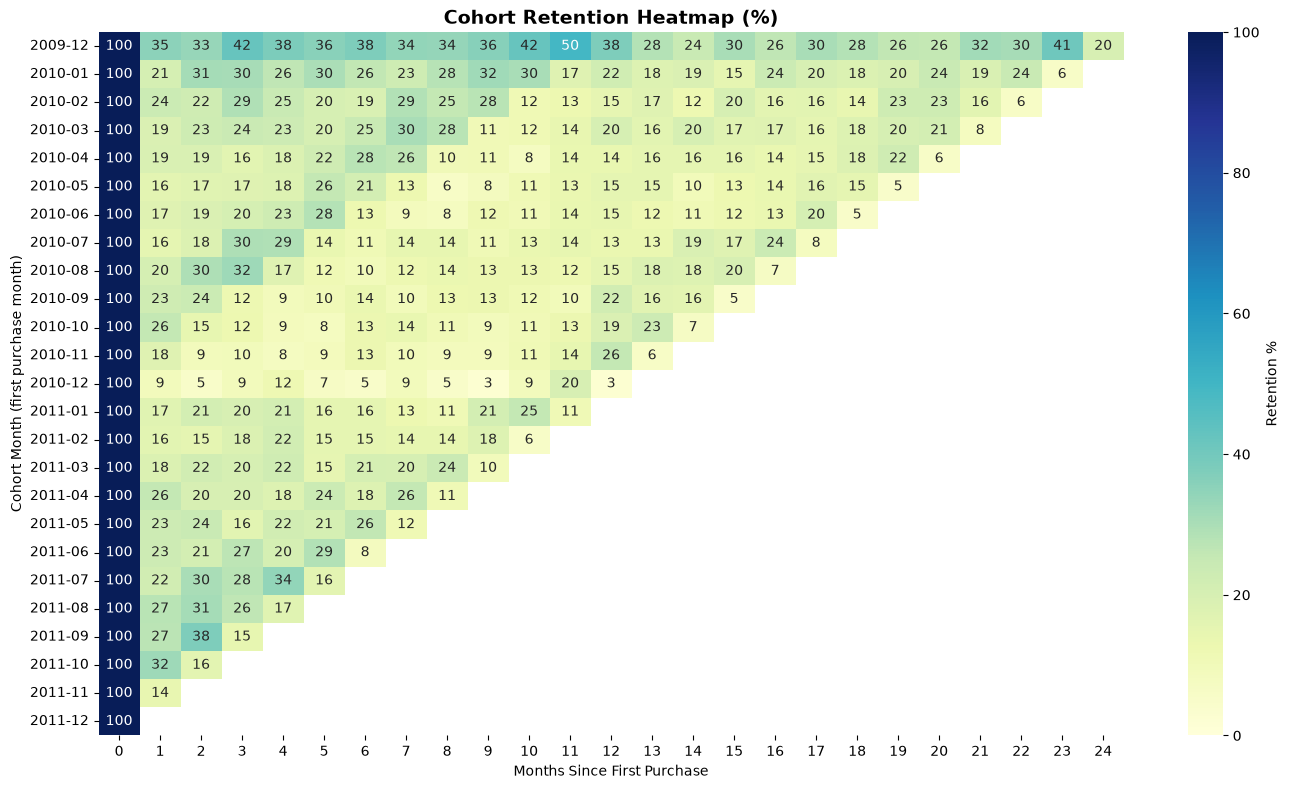

Saved: outputs/figures/cohort_heatmap.png


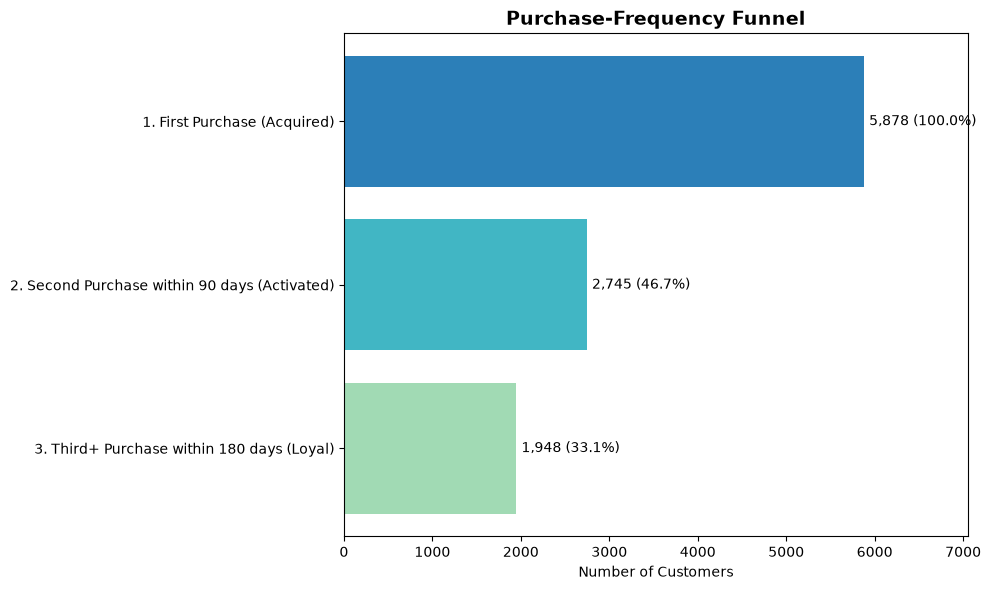

Saved: outputs/figures/funnel_chart.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PHASE 4A — COHORT RETENTION HEATMAP
# ============================================================

retention_table = pd.read_csv('../outputs/retention_table.csv', index_col=0)
# Column names load as strings ('0','1','2'...) -- convert to int for clean ordering
retention_table.columns = retention_table.columns.astype(int)

plt.figure(figsize=(14, 8))
sns.heatmap(
    retention_table,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    vmin=0, vmax=100,
    cbar_kws={'label': 'Retention %'}
)
plt.title('Cohort Retention Heatmap (%)', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month (first purchase month)')
plt.tight_layout()
plt.savefig('../outputs/figures/cohort_heatmap.png', dpi=150)
plt.show()

print("Saved: outputs/figures/cohort_heatmap.png")


# ============================================================
# PHASE 4B — FUNNEL CHART
# ============================================================

funnel = pd.read_csv('../outputs/funnel_table.csv')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(funnel['Stage'], funnel['Customers'], color=['#2c7fb8', '#41b6c4', '#a1dab4'])

# Label each bar with customer count + % of total
for bar, customers, pct in zip(bars, funnel['Customers'], funnel['% of Total']):
    ax.text(
        bar.get_width() + (funnel['Customers'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{customers:,} ({pct}%)",
        va='center', fontsize=10
    )

ax.invert_yaxis()  # Stage 1 on top, like a real funnel reading top-to-bottom
ax.set_xlim(0, funnel['Customers'].max() * 1.2)  # extra room so labels don't get clipped
ax.set_xlabel('Number of Customers')
ax.set_title('Purchase-Frequency Funnel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/funnel_chart.png', dpi=150)
plt.show()

print("Saved: outputs/figures/funnel_chart.png")

In [ ]:
import pandas as pd
import os

RAW_PATH = '../data/raw/online_retail_II.csv'
OUTPUT_PATH = '../data/raw/online_retail_II_cleaned.parquet'

print("Loading raw CSV (this may take a minute for a large file)...")
df = pd.read_csv(RAW_PATH, encoding='ISO-8859-1')
raw_size = os.path.getsize(RAW_PATH)
print(f"Raw file size: {raw_size / 1e6:.1f} MB, {len(df):,} rows")

df = df.dropna(subset=['Customer ID'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['Price']

df.to_parquet(OUTPUT_PATH, engine='pyarrow', compression='snappy')
new_size = os.path.getsize(OUTPUT_PATH)

print(f"\nCleaned Parquet size: {new_size / 1e6:.1f} MB, {len(df):,} rows")
print(f"Size reduction: {(1 - new_size/raw_size)*100:.1f}%")